In [26]:
import numpy as np
from scipy.io import wavfile
import matplotlib.pyplot as plt
import sounddevice as sd
import matplotlib.image as mpimg
from scipy.signal import convolve2d

In [27]:
Fs, u = wavfile.read('data/voice_short.wav')

# Normalize
u = u.astype(np.float32)
u = u / np.max(np.abs(u))

# Designing the Impulse Response 
g = np.zeros(Fs + 1)

# First element is original audio
g[0] = 1.0

# half-volume echo
g[Fs] = 0.5 

# numpy convolve
y = np.convolve(u, g, mode='full')


/tmp/ipykernel_23113/2882580341.py:1: WavFileWarning: Chunk (non-data) not understood, skipping it.
  Fs, u = wavfile.read('data/voice_short.wav')


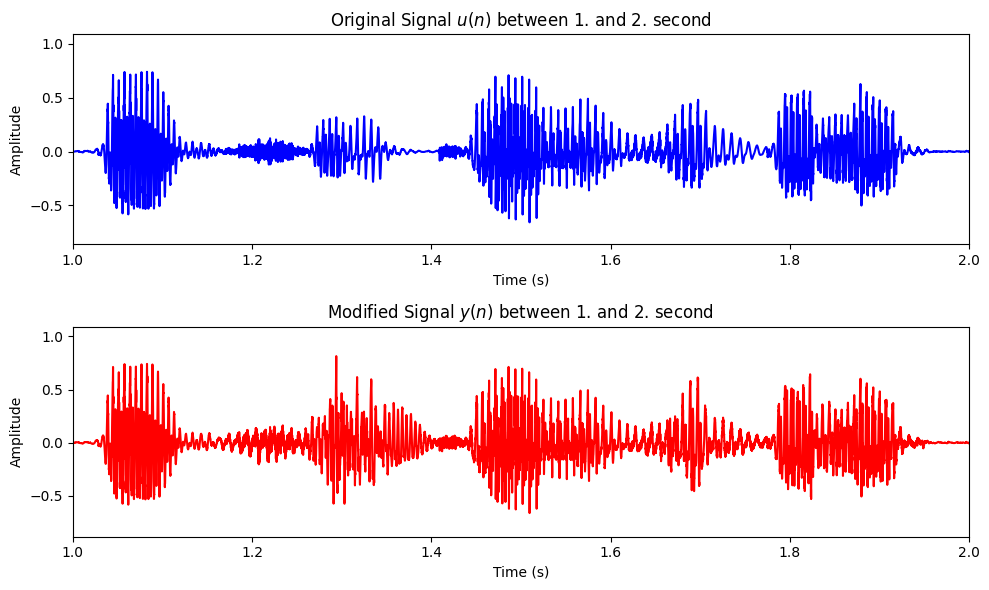

In [28]:

t_u = np.arange(len(u)) / Fs
t_y = np.arange(len(y)) / Fs

plt.figure(figsize=(10, 6))

# Plot original signal
plt.subplot(2, 1, 1)
plt.plot(t_u, u, color='blue')
plt.xlim(1, 2) # Restrict to 1s - 2s
plt.title('Original Signal $u(n)$ between 1. and 2. second')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

# Plot modified signal
plt.subplot(2, 1, 2)
plt.plot(t_y, y, color='red')
plt.xlim(1, 2) # Restrict to 1s - 2s
plt.title('Modified Signal $y(n)$ between 1. and 2. second')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')

plt.tight_layout()
plt.show()

# Original Audio

In [29]:
# Play the original audio
sd.play(u, Fs)
sd.wait() 

# Modified Audio

In [30]:
# Play the audio with echo
sd.play(y, Fs)
sd.wait()

In [31]:
img = mpimg.imread('data/fruit_grey.jpg')
if img.ndim == 3:
    img = img[:, :, 0] 

# Convert to float 
img = img.astype(float)

# Original Image

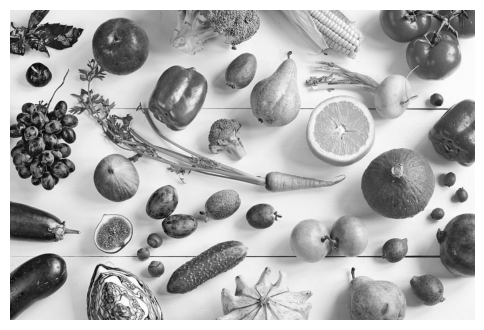

In [43]:
plt.figure(figsize=(6, 6))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

# Standard Laplacian 

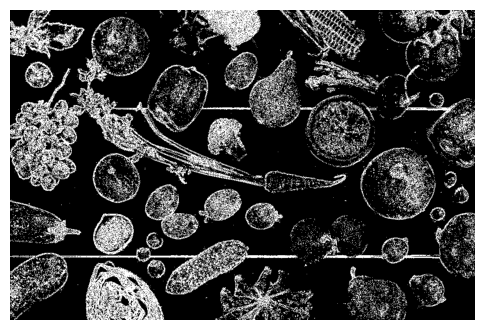

In [42]:
g1 = np.array([[ 0, -1,  0],
               [-1,  4, -1],
               [ 0, -1,  0]])

img_g1 = convolve2d(img, g1, mode='same', boundary='symm')

edges_g1 = np.abs(img_g1)

threshold_value = 30 
bw_g1 = edges_g1 > threshold_value

plt.figure(figsize=(6, 6))
plt.imshow(bw_g1, cmap='gray')
plt.axis('off')
plt.show()

# Stronger Laplacian

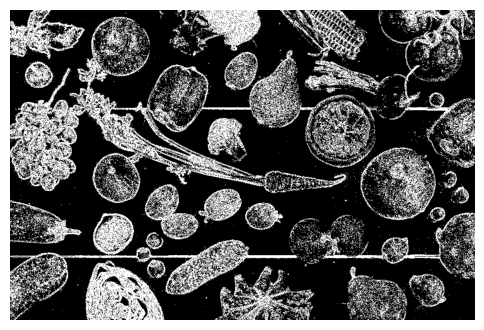

In [44]:
g2 = np.array([[-1, -1, -1],
               [-1,  8, -1],
               [-1, -1, -1]])

img_g2 = convolve2d(img, g2, mode='same', boundary='symm')

edges_g2 = np.abs(img_g2)

threshold_value_g2 = 50 
bw_g2 = edges_g2 > threshold_value_g2

plt.figure(figsize=(6, 6))
plt.imshow(bw_g2, cmap='gray')
plt.axis('off')
plt.show()

# Box Blur

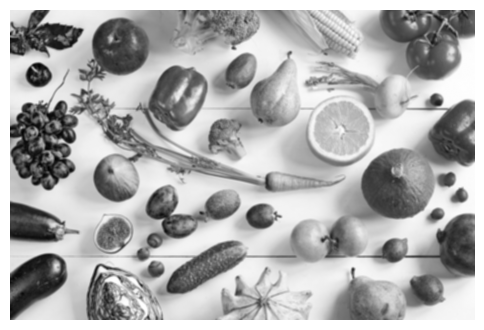

In [45]:
g3 = np.ones((5, 5)) / 25.0

img_g3 = convolve2d(img, g3, mode='same', boundary='symm')

plt.figure(figsize=(6, 6))
plt.imshow(img_g3, cmap='gray')
plt.axis('off')
plt.show()

# Gaussian Blur

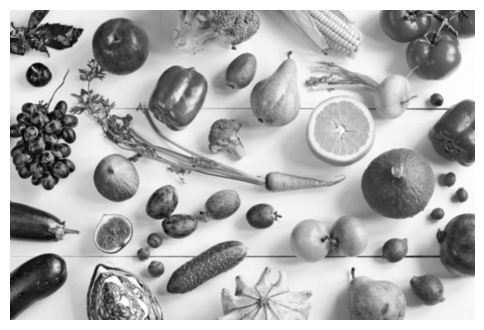

In [46]:
g4 = np.array([[1,  4,  6,  4, 1],
               [4, 16, 24, 16, 4],
               [6, 24, 36, 24, 6],
               [4, 16, 24, 16, 4],
               [1,  4,  6,  4, 1]]) / 256.0

img_g4 = convolve2d(img, g4, mode='same', boundary='symm')

plt.figure(figsize=(6, 6))
plt.imshow(img_g4, cmap='gray')
plt.axis('off')
plt.show()

# Conclusion

This assignment demonstrated the practical applications of convolution in both 1D and 2D signal processing. Through audio convolution, we created an echo effect by defining a custom impulse response, illustrating how mathematical convolution translates to real-world audio effects. 

In image processing, we explored various convolution kernels including Laplacian operators for edge detection and blur filters for image smoothing. Each kernel transformed the image differently, showcasing how convolution is a fundamental tool for signal filtering and feature extraction across domains.